# 05 - Avaliacao em 2024, extremos e ablation

**Objetivo:** verificar se as previsoes funcionam, especialmente quando o rio sobe muito.

Este notebook mede:
- erro medio;
- recall/precision de grandes subidas;
- subestimacao em eventos;
- contribuicao de cada grupo de variaveis;
- comportamento no evento de 14/02/2024.

### Saidas
Todas as tabelas completas vao para `outputs/tables/` e as previsoes para `outputs/predictions/`.

In [29]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------------
# Localiza a raiz do projeto e o dataset de forma robusta.
# Funciona se o notebook estiver em Field-Project/notebooks.
# ------------------------------------------------------------------
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

RAW_PARENT = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
PREDICTIONS = OUTPUTS / "predictions"

for p in [INTERIM, PROCESSED, MODELS, FIGURES, TABLES, PREDICTIONS]:
    p.mkdir(parents=True, exist_ok=True)

def find_dataset_root(raw_parent: Path) -> Path:
    """Procura uma pasta que contenha Data/SHP e Data/Telemetric_Time_Series."""
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "SHP").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError(
        "Nao encontrei o dataset. Extraia o .rar dentro de data/raw/ "
        "mantendo a pasta Data/ com SHP/, Radar/ e Telemetric_Time_Series/."
    )

RAW = find_dataset_root(RAW_PARENT)
DATA = RAW / "Data"
SHP = DATA / "SHP"
TELE = DATA / "Telemetric_Time_Series"
RADAR = DATA / "Radar"

print("ROOT:", ROOT)
print("Dataset:", RAW)

ROOT: C:\Users\osmar\Área de Trabalho\Field-Project
Dataset: C:\Users\osmar\Área de Trabalho\Field-Project\data\raw\TTI-HydroMet_Dataset_version2


In [30]:
def save_table(df, stem, preview_rows=15, sort_by=None, ascending=True):
    """
    Salva a tabela completa em CSV e HTML e mostra apenas uma amostra no notebook.
    Isso evita outputs gigantes e facilita abrir a tabela fora do Jupyter.
    """
    z = df.copy()
    if sort_by is not None and sort_by in z.columns:
        z = z.sort_values(sort_by, ascending=ascending)

    csv_path = TABLES / f"{stem}.csv"
    html_path = TABLES / f"{stem}.html"

    z.to_csv(csv_path, index=False)
    z.to_html(html_path, index=False)

    display(Markdown(
        f"**Tabela completa salva em:**  \n"
        f"- `{csv_path.relative_to(ROOT)}`  \n"
        f"- `{html_path.relative_to(ROOT)}`  \n"
        f"Mostrando apenas as primeiras {min(preview_rows, len(z))} linhas:"
    ))
    display(z.head(preview_rows))
    return z

def save_figure(fig, stem, dpi=220):
    """Salva uma figura em PNG e a mantem visivel no notebook."""
    path = FIGURES / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(Markdown(f"**Figura salva em:** `{path.relative_to(ROOT)}`"))
    return path

In [31]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    precision_recall_fscore_support
)
from xgboost import XGBRegressor
import joblib

x = pd.read_parquet(PROCESSED / "features_causal.parquet")
master = pd.read_parquet(PROCESSED / "master_base.parquet")

with open(MODELS / "feature_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

feature_cols = metadata["features"]
ridge_features = metadata["ridge_features"]
stage_cols = [c for c in feature_cols if c.startswith("stage_")]
rain_cols = [c for c in feature_cols if c.startswith("rain_")]
up_cols = [c for c in feature_cols if c.startswith("up_")]

In [32]:
def get_split(df, horizon, split_name):
    target = f"target_delta_{horizon}m"
    z = df[df["split"] == split_name].copy()
    z = z[z["stage_now"].notna() & z[target].notna()]
    return z, target

def regression_metrics(y_true, y_pred):
    return {
        "MAE_m": mean_absolute_error(y_true, y_pred),
        "RMSE_m": mean_squared_error(y_true, y_pred) ** 0.5,
    }

def event_classification(y_true_delta, y_pred_delta, threshold):
    y_true = (np.asarray(y_true_delta) >= threshold).astype(int)
    y_pred = (np.asarray(y_pred_delta) >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return {
        "threshold_m": threshold,
        "n_real_events": int(y_true.sum()),
        "n_pred_events": int(y_pred.sum()),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [33]:
rows = []
predictions_by_horizon = {}

for horizon in [60, 120, 240]:
    test, target = get_split(x, horizon, "test_2024")

    pred_persistence = np.zeros(len(test))
    pred_trend = test["stage_change_1h"].fillna(0).to_numpy() * (horizon / 60)

    ridge = joblib.load(MODELS / f"ridge_dev_{horizon}m.joblib")
    pred_ridge = ridge.predict(test[ridge_features])

    xgb = XGBRegressor()
    xgb.load_model(MODELS / f"xgb_dev_{horizon}m.json")
    pred_xgb = xgb.predict(test[feature_cols])

    pred_df = test[["stage_now", target]].copy()
    pred_df["pred_persistence"] = pred_persistence
    pred_df["pred_trend"] = pred_trend
    pred_df["pred_ridge"] = pred_ridge
    pred_df["pred_xgb"] = pred_xgb
    predictions_by_horizon[horizon] = pred_df
    pred_df.to_csv(PREDICTIONS / f"predictions_2024_{horizon}min.csv")

    for model_name, pred in [
        ("persistence", pred_persistence),
        ("trend", pred_trend),
        ("ridge", pred_ridge),
        ("xgb", pred_xgb),
    ]:
        m = regression_metrics(test[target], pred)
        rows.append({"horizon_min": horizon, "model": model_name, **m})

metrics_2024 = pd.DataFrame(rows)
metrics_2024["MAE_cm"] = 100 * metrics_2024["MAE_m"]
metrics_2024["RMSE_cm"] = 100 * metrics_2024["RMSE_m"]
save_table(metrics_2024, "metrics_2024", preview_rows=20)

**Tabela completa salva em:**  
- `outputs\tables\metrics_2024.csv`  
- `outputs\tables\metrics_2024.html`  
Mostrando apenas as primeiras 12 linhas:

,horizon_min,model,MAE_m,RMSE_m,MAE_cm,RMSE_cm
0,60,persistence,0.065838,0.212194,6.583826,21.219444
1,60,trend,0.060462,0.243873,6.046176,24.387322
2,60,ridge,0.052400,0.140043,5.239964,14.004301
3,60,xgb,0.031430,0.112233,3.143020,11.223347
4,120,persistence,0.120498,0.346191,12.049832,34.619075
5,120,trend,0.131872,0.481409,13.187224,48.140905
6,120,ridge,0.094754,0.243280,9.475382,24.327953
7,120,xgb,0.061750,0.213907,6.174969,21.390652
8,240,persistence,0.204824,0.510597,20.482403,51.059679
9,240,trend,0.281496,0.947385,28.149620,94.738511


,horizon_min,model,MAE_m,RMSE_m,MAE_cm,RMSE_cm
0,60,persistence,0.065838,0.212194,6.583826,21.219444
1,60,trend,0.060462,0.243873,6.046176,24.387322
2,60,ridge,0.052400,0.140043,5.239964,14.004301
3,60,xgb,0.031430,0.112233,3.143020,11.223347
4,120,persistence,0.120498,0.346191,12.049832,34.619075
5,120,trend,0.131872,0.481409,13.187224,48.140905
6,120,ridge,0.094754,0.243280,9.475382,24.327953
7,120,xgb,0.061750,0.213907,6.174969,21.390652
8,240,persistence,0.204824,0.510597,20.482403,51.059679
9,240,trend,0.281496,0.947385,28.149620,94.738511


**Figura salva em:** `outputs\figures\rmse_2024_horizons.png`

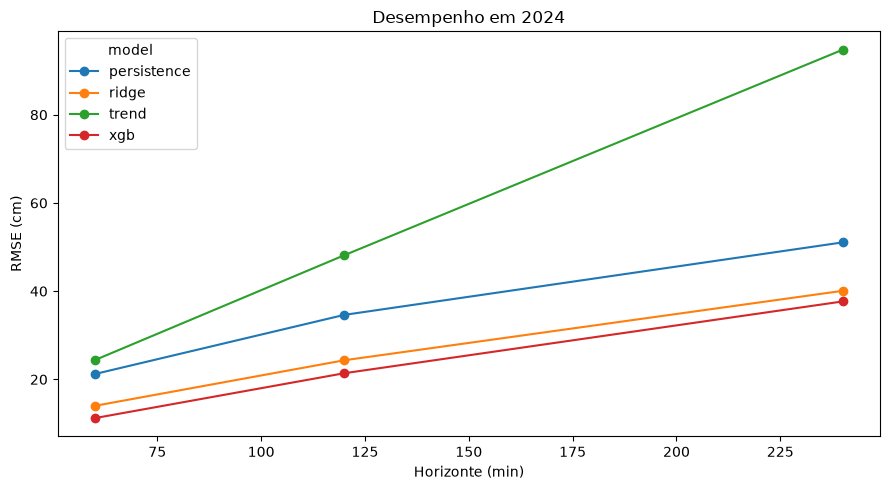

In [34]:
# Figura compacta em vez de imprimir uma tabela enorme.
pivot = metrics_2024.pivot(index="horizon_min", columns="model", values="RMSE_cm")
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(marker="o", ax=ax)
ax.set_ylabel("RMSE (cm)")
ax.set_xlabel("Horizonte (min)")
ax.set_title("Desempenho em 2024")
plt.tight_layout()
save_figure(fig, "rmse_2024_horizons")
plt.show()

**Tabela completa salva em:**  
- `outputs\tables\event_metrics_2024.csv`  
- `outputs\tables\event_metrics_2024.html`  
Mostrando apenas as primeiras 12 linhas:

,threshold_m,n_real_events,n_pred_events,precision,recall,f1,horizon_min
0,0.2,1084,1317,0.665148,0.808118,0.729696,60
1,0.5,605,683,0.626647,0.707438,0.664596,60
2,1.0,307,260,0.757692,0.641694,0.694885,60
3,2.0,114,66,0.772727,0.447368,0.566667,60
4,0.2,1618,1546,0.685640,0.655130,0.670038,120
5,0.5,1040,795,0.757233,0.578846,0.656131,120
6,1.0,639,401,0.753117,0.472613,0.580769,120
7,2.0,313,124,0.774194,0.306709,0.439359,120
8,0.2,2635,3325,0.376842,0.475522,0.420470,240
9,0.5,1679,1034,0.652805,0.402025,0.497604,240


**Figura salva em:** `outputs\figures\recall_extremos_2024.png`

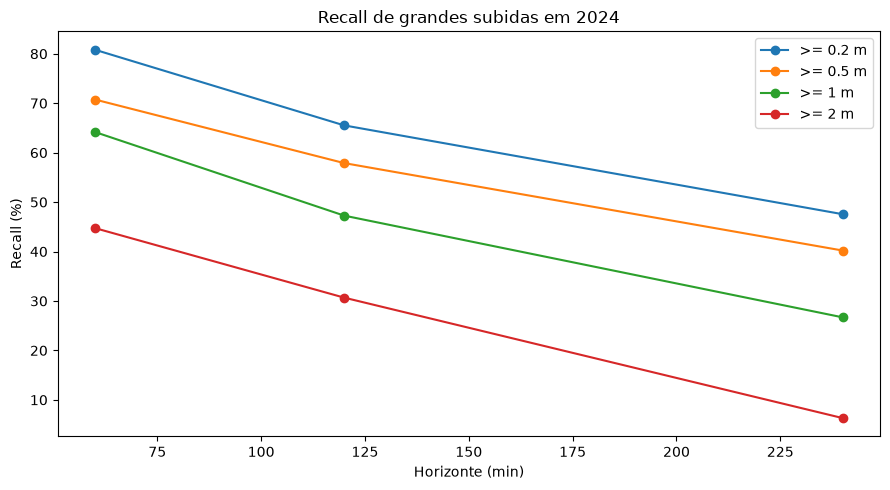

In [35]:
event_rows = []
for horizon in [60, 120, 240]:
    pred_df = predictions_by_horizon[horizon]
    target = f"target_delta_{horizon}m"
    for threshold in [0.2, 0.5, 1.0, 2.0]:
        r = event_classification(pred_df[target], pred_df["pred_xgb"], threshold)
        r["horizon_min"] = horizon
        event_rows.append(r)

event_metrics = pd.DataFrame(event_rows)
save_table(event_metrics, "event_metrics_2024", preview_rows=20)

# Grafico de recall para leitura humana.
fig, ax = plt.subplots(figsize=(9, 5))
for th in sorted(event_metrics["threshold_m"].unique()):
    z = event_metrics[event_metrics["threshold_m"] == th]
    ax.plot(z["horizon_min"], 100*z["recall"], marker="o", label=f">= {th:g} m")
ax.set_xlabel("Horizonte (min)")
ax.set_ylabel("Recall (%)")
ax.set_title("Recall de grandes subidas em 2024")
ax.legend()
plt.tight_layout()
save_figure(fig, "recall_extremos_2024")
plt.show()

In [36]:
def conditional_rise_metrics(df, target, pred_col, thresholds=(0.2, 0.5, 1.0, 2.0)):
    rows = []
    for th in thresholds:
        z = df[df[target] >= th]
        if len(z) == 0:
            continue
        error = z[pred_col] - z[target]
        rows.append({
            "threshold_m": th,
            "n": len(z),
            "MAE_m": np.abs(error).mean(),
            "bias_m": error.mean(),
            "underprediction_rate": (error < 0).mean(),
        })
    return pd.DataFrame(rows)

cond = conditional_rise_metrics(
    predictions_by_horizon[120],
    "target_delta_120m",
    "pred_xgb",
)
save_table(cond, "conditional_extremes_120m", preview_rows=10)

**Tabela completa salva em:**  
- `outputs\tables\conditional_extremes_120m.csv`  
- `outputs\tables\conditional_extremes_120m.html`  
Mostrando apenas as primeiras 4 linhas:

,threshold_m,n,MAE_m,bias_m,underprediction_rate
0,0.2,1618,0.689012,-0.505540,0.733004
1,0.5,1040,0.935977,-0.756041,0.775000
2,1.0,639,1.256525,-1.119809,0.835681
3,2.0,313,1.724633,-1.614004,0.875399


,threshold_m,n,MAE_m,bias_m,underprediction_rate
0,0.2,1618,0.689012,-0.505540,0.733004
1,0.5,1040,0.935977,-0.756041,0.775000
2,1.0,639,1.256525,-1.119809,0.835681
3,2.0,313,1.724633,-1.614004,0.875399


**Tabela completa salva em:**  
- `outputs\tables\ablation_120m.csv`  
- `outputs\tables\ablation_120m.html`  
Mostrando apenas as primeiras 3 linhas:

,features,n_features,MAE_cm,RMSE_cm
0,stage_only,22,11.639617,36.768223
1,stage_plus_rain,145,8.682623,25.955092
2,stage_rain_upstream,166,7.736901,25.475502


**Figura salva em:** `outputs\figures\ablation_120m.png`

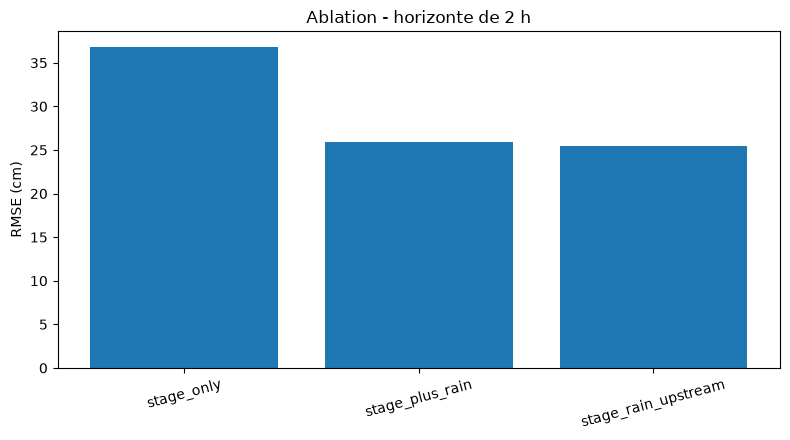

In [37]:
feature_sets = {
    "stage_only": stage_cols,
    "stage_plus_rain": stage_cols + rain_cols,
    "stage_rain_upstream": stage_cols + rain_cols + up_cols,
}

train, target = get_split(x, 120, "train")
valid, _ = get_split(x, 120, "validation")

ablation_rows = []
for name, cols in feature_sets.items():
    model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_estimators=160,
        learning_rate=0.06,
        max_depth=6,
        min_child_weight=20,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_lambda=5.0,
        n_jobs=-1,
        random_state=42,
    )
    model.fit(train[cols], train[target])
    pred = model.predict(valid[cols])
    m = regression_metrics(valid[target], pred)
    ablation_rows.append({
        "features": name,
        "n_features": len(cols),
        "MAE_cm": 100*m["MAE_m"],
        "RMSE_cm": 100*m["RMSE_m"],
    })

ablation = pd.DataFrame(ablation_rows)
save_table(ablation, "ablation_120m", preview_rows=10)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ablation["features"], ablation["RMSE_cm"])
ax.set_ylabel("RMSE (cm)")
ax.set_title("Ablation - horizonte de 2 h")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
save_figure(fig, "ablation_120m")
plt.show()

**Figura salva em:** `outputs\figures\event_2024_02_14_120.png`

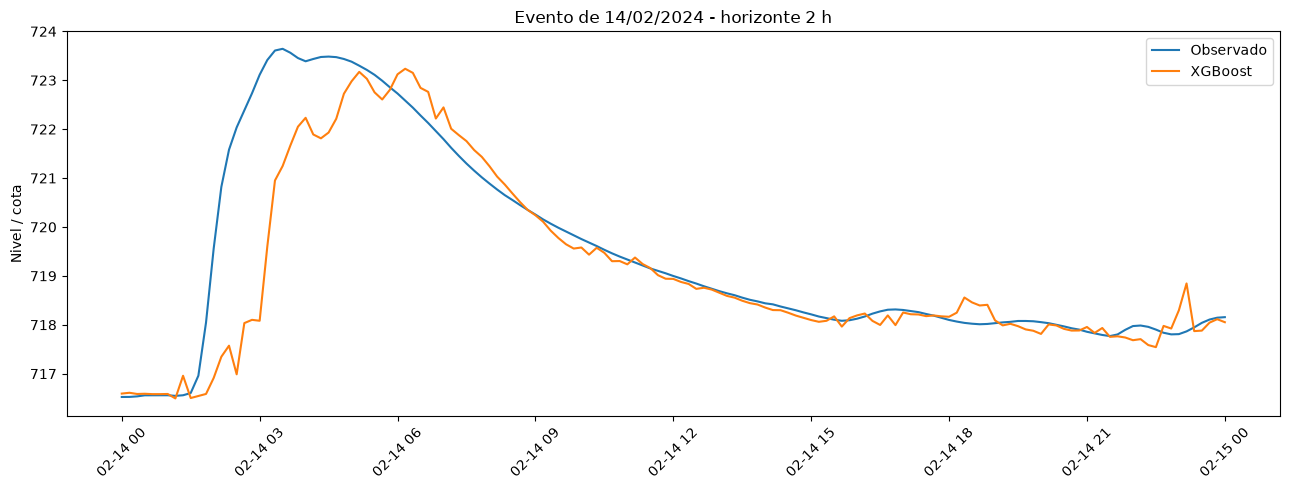

In [38]:
horizon = 120
pred = predictions_by_horizon[horizon].copy()
pred["target_time"] = pred.index + pd.Timedelta(minutes=horizon)
pred["pred_stage"] = pred["stage_now"] + pred["pred_xgb"]
pred["true_future_stage"] = pred["stage_now"] + pred["target_delta_120m"]

event = pred[
    (pred["target_time"] >= "2024-02-14 00:00")
    & (pred["target_time"] <= "2024-02-15 00:00")
].copy()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(event["target_time"], event["true_future_stage"], label="Observado")
ax.plot(event["target_time"], event["pred_stage"], label="XGBoost")
ax.set_ylabel("Nivel / cota")
ax.set_title("Evento de 14/02/2024 - horizonte 2 h")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_figure(fig, "event_2024_02_14_120")
plt.show()

event.to_csv(PREDICTIONS / "event_2024_02_14_120.csv")

## Relatorios visuais da avaliacao de 2024

Esta secao gera automaticamente:

- **HTML estatico** para leitura;
- **PDF multipagina**;
- **dashboard HTML interativo**;
- tabelas de previsao por horario em formato humano;
- desempenho por faixa de subida;
- deteccao de eventos severos;
- maiores episodios hidrologicos.

A analise de "evitar perdas" e tratada como **proxy operacional**, pois a base nao contem valores de perdas humanas ou monetarias.


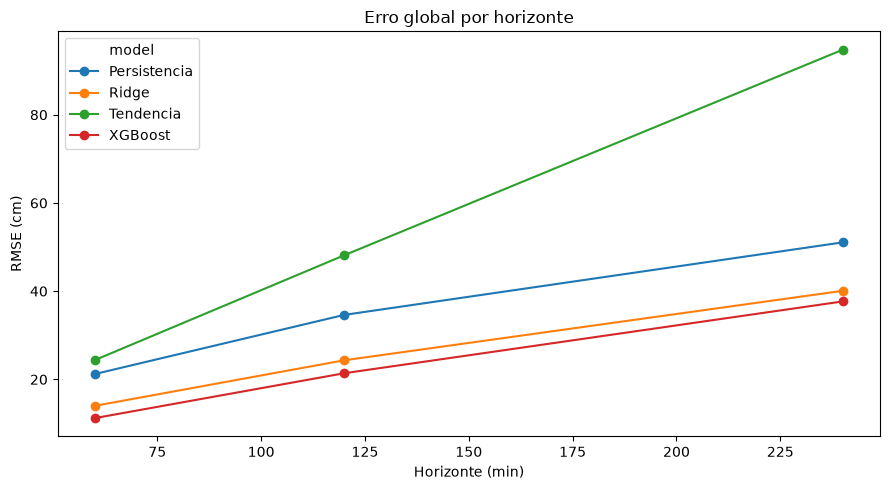

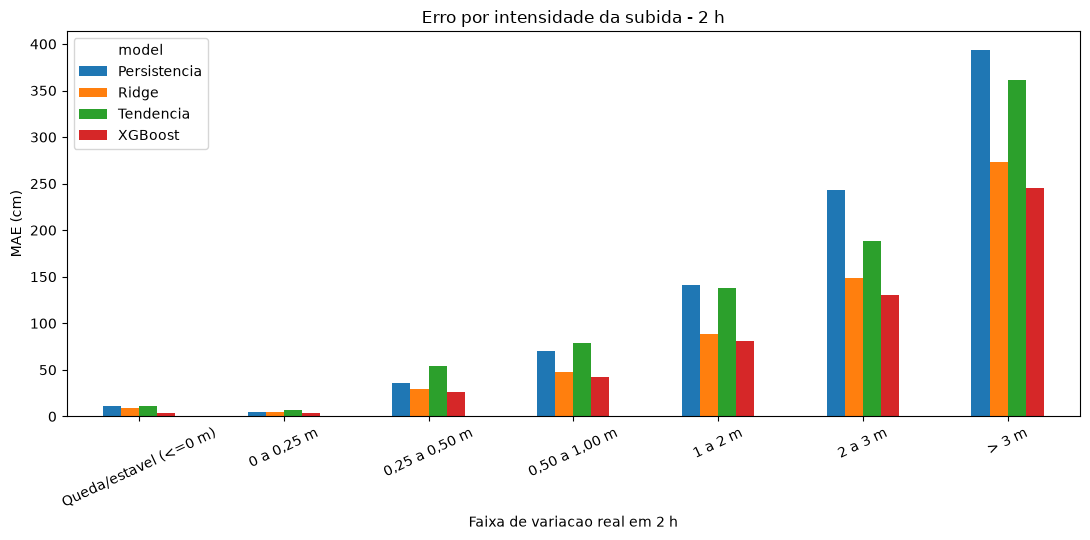

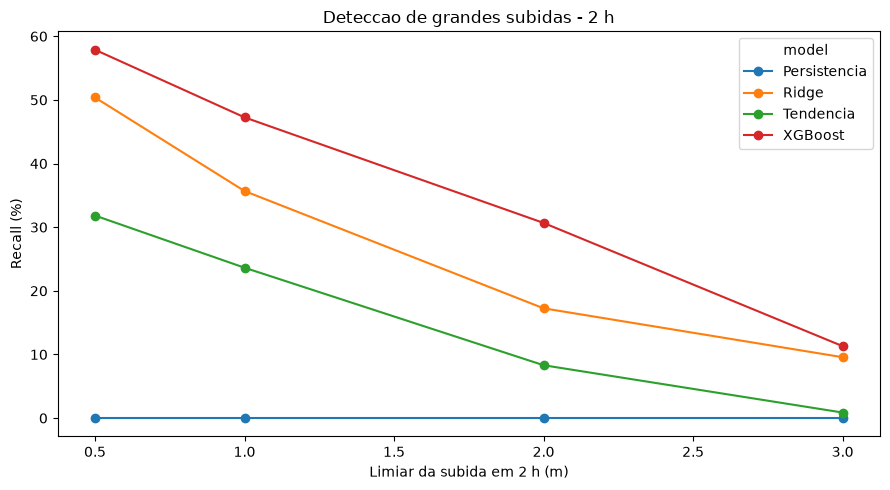

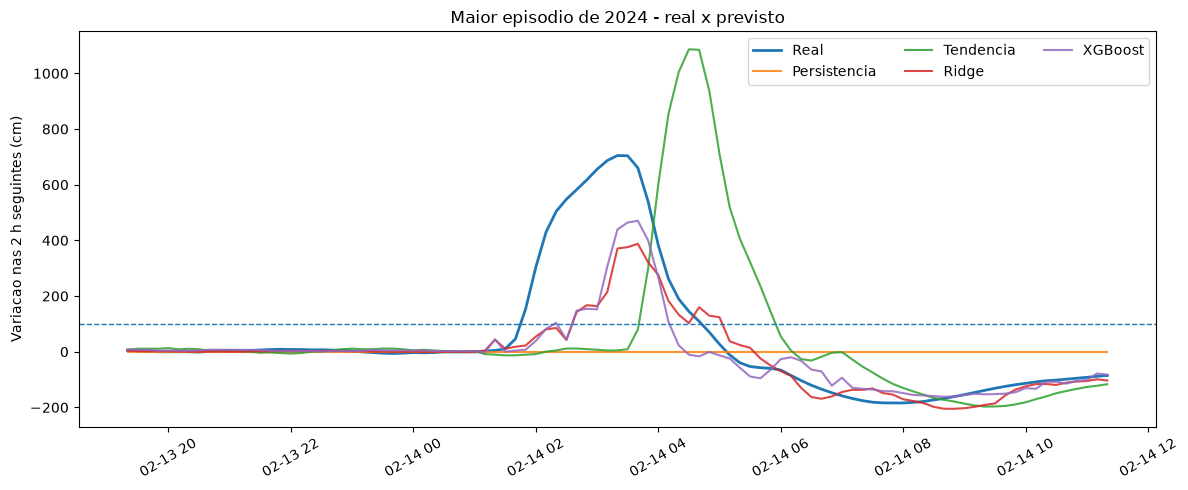

Relatorios gerados:
C:\Users\osmar\Área de Trabalho\Field-Project\outputs\reports\html\relatorio_modelos_2024.html
C:\Users\osmar\Área de Trabalho\Field-Project\outputs\reports\pdf\relatorio_modelos_2024.pdf
C:\Users\osmar\Área de Trabalho\Field-Project\outputs\reports\dashboards\dashboard_modelos_2024.html


In [39]:
# ============================================================
# RELATORIOS VISUAIS E TABELAS HUMANAS - 2024
# ============================================================
from pathlib import Path
import base64
from matplotlib.backends.backend_pdf import PdfPages

try:
    import plotly.graph_objects as go
    import plotly.io as pio
except ImportError as exc:
    raise ImportError(
        "Plotly nao esta instalado. No terminal com (.venv), execute: "
        "python -m pip install plotly"
    ) from exc

REPORTS = ROOT / "outputs" / "reports"
REPORT_HTML = REPORTS / "html"
REPORT_PDF = REPORTS / "pdf"
REPORT_DASHBOARDS = REPORTS / "dashboards"
for p in [REPORT_HTML, REPORT_PDF, REPORT_DASHBOARDS]:
    p.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    "persistence": "Persistencia",
    "trend": "Tendencia",
    "ridge": "Ridge",
    "xgb": "XGBoost",
}
MODEL_PRED_COLS = {
    "persistence": "pred_persistence",
    "trend": "pred_trend",
    "ridge": "pred_ridge",
    "xgb": "pred_xgb",
}
SEVERITY_BINS = [-np.inf, 0, 0.25, 0.50, 1.0, 2.0, 3.0, np.inf]
SEVERITY_LABELS = [
    "Queda/estavel (<=0 m)",
    "0 a 0,25 m",
    "0,25 a 0,50 m",
    "0,50 a 1,00 m",
    "1 a 2 m",
    "2 a 3 m",
    "> 3 m",
]
ALERT_THRESHOLDS = [0.5, 1.0, 2.0, 3.0]


def human_prediction_table(pred_df, horizon):
    target = f"target_delta_{horizon}m"
    z = pred_df.copy()
    z["prediction_time"] = z.index
    z["target_time"] = z.index + pd.Timedelta(minutes=horizon)
    z["real_delta_m"] = z[target]
    z["real_delta_cm"] = 100 * z[target]
    z["real_stage_m"] = z["stage_now"] + z[target]

    for model, pred_col in MODEL_PRED_COLS.items():
        z[f"{model}_delta_cm"] = 100 * z[pred_col]
        z[f"{model}_stage_m"] = z["stage_now"] + z[pred_col]
        z[f"{model}_error_cm"] = 100 * (z[pred_col] - z[target])
        z[f"{model}_abs_error_cm"] = z[f"{model}_error_cm"].abs()

    cols = [
        "prediction_time", "target_time", "stage_now",
        "real_delta_cm", "real_stage_m",
    ]
    for model in MODEL_PRED_COLS:
        cols += [
            f"{model}_delta_cm", f"{model}_stage_m",
            f"{model}_error_cm", f"{model}_abs_error_cm",
        ]
    return z[cols].reset_index(drop=True)


def global_metrics(predictions_by_horizon):
    rows = []
    for horizon, pred_df in predictions_by_horizon.items():
        target = f"target_delta_{horizon}m"
        y = pred_df[target].to_numpy()
        for model, pred_col in MODEL_PRED_COLS.items():
            p = pred_df[pred_col].to_numpy()
            err = 100 * (p - y)
            ae = np.abs(err)
            rows.append({
                "horizon_min": horizon,
                "model": MODEL_LABELS[model],
                "n": len(y),
                "MAE_cm": ae.mean(),
                "RMSE_cm": np.sqrt(np.mean(err**2)),
                "median_abs_error_cm": np.median(ae),
                "max_abs_error_cm": ae.max(),
                "bias_cm": err.mean(),
                "within_10cm_pct": 100*np.mean(ae <= 10),
                "within_20cm_pct": 100*np.mean(ae <= 20),
                "within_50cm_pct": 100*np.mean(ae <= 50),
            })
    return pd.DataFrame(rows)


def severity_metrics(predictions_by_horizon):
    rows = []
    for horizon, pred_df in predictions_by_horizon.items():
        target = f"target_delta_{horizon}m"
        z = pred_df.copy()
        z["severity_band"] = pd.cut(
            z[target], bins=SEVERITY_BINS, labels=SEVERITY_LABELS
        )
        for band in SEVERITY_LABELS:
            b = z[z["severity_band"] == band]
            if b.empty:
                continue
            y = b[target].to_numpy()
            for model, pred_col in MODEL_PRED_COLS.items():
                p = b[pred_col].to_numpy()
                err = 100*(p-y)
                ae = np.abs(err)
                rows.append({
                    "horizon_min": horizon,
                    "severity_band": band,
                    "model": MODEL_LABELS[model],
                    "n": len(b),
                    "MAE_cm": ae.mean(),
                    "RMSE_cm": np.sqrt(np.mean(err**2)),
                    "max_abs_error_cm": ae.max(),
                    "bias_cm": err.mean(),
                    "underprediction_pct": 100*np.mean(p < y),
                    "within_20cm_pct": 100*np.mean(ae <= 20),
                    "within_50cm_pct": 100*np.mean(ae <= 50),
                })
    return pd.DataFrame(rows)


def alert_metrics(predictions_by_horizon):
    rows = []
    for horizon, pred_df in predictions_by_horizon.items():
        target = f"target_delta_{horizon}m"
        y = pred_df[target].to_numpy()
        for th in ALERT_THRESHOLDS:
            real = y >= th
            for model, pred_col in MODEL_PRED_COLS.items():
                predicted = pred_df[pred_col].to_numpy() >= th
                tp = int(np.sum(real & predicted))
                fn = int(np.sum(real & ~predicted))
                fp = int(np.sum(~real & predicted))
                recall = tp/(tp+fn) if tp+fn else np.nan
                precision = tp/(tp+fp) if tp+fp else np.nan
                f1 = (
                    2*precision*recall/(precision+recall)
                    if precision == precision and recall == recall and precision+recall > 0
                    else np.nan
                )
                rows.append({
                    "horizon_min": horizon,
                    "threshold_m": th,
                    "model": MODEL_LABELS[model],
                    "real_events": int(real.sum()),
                    "predicted_alerts": int(predicted.sum()),
                    "true_positives": tp,
                    "missed_events": fn,
                    "false_alerts": fp,
                    "recall_pct": 100*recall if recall == recall else np.nan,
                    "precision_pct": 100*precision if precision == precision else np.nan,
                    "f1": f1,
                    "lead_time_hours": horizon/60,
                })
    return pd.DataFrame(rows)


def severe_episodes(pred_df, horizon=120, threshold=1.0, gap_hours=6):
    target = f"target_delta_{horizon}m"
    z = pred_df[pred_df[target] >= threshold].copy().sort_index()
    if z.empty:
        return pd.DataFrame()
    new_episode = z.index.to_series().diff().gt(pd.Timedelta(hours=gap_hours)).fillna(True)
    z["episode_id"] = new_episode.cumsum().to_numpy()
    rows = []
    for eid, g in z.groupby("episode_id"):
        idx = g[target].idxmax()
        r = g.loc[idx]
        out = {
            "episode_id": int(eid),
            "prediction_time_peak": idx,
            "target_time_peak": idx + pd.Timedelta(minutes=horizon),
            "real_peak_delta_cm": 100*float(r[target]),
            "stage_now_m": float(r["stage_now"]),
            "real_future_stage_m": float(r["stage_now"] + r[target]),
        }
        for model, pred_col in MODEL_PRED_COLS.items():
            pred = float(r[pred_col])
            out[f"{model}_pred_delta_cm"] = 100*pred
            out[f"{model}_abs_error_cm"] = 100*abs(pred-r[target])
            out[f"{model}_detected"] = bool(pred >= threshold)
        rows.append(out)
    return pd.DataFrame(rows).sort_values("real_peak_delta_cm", ascending=False)


# Tabelas humanas por horizonte.
human_tables = {}
for horizon, pred_df in predictions_by_horizon.items():
    h = human_prediction_table(pred_df, horizon)
    human_tables[horizon] = h
    h.to_csv(PREDICTIONS / f"predictions_2024_{horizon}min_human.csv", index=False)
    h.to_html(PREDICTIONS / f"predictions_2024_{horizon}min_human.html", index=False)

metrics_full = global_metrics(predictions_by_horizon)
metrics_severity = severity_metrics(predictions_by_horizon)
metrics_alert = alert_metrics(predictions_by_horizon)
episodes_120 = severe_episodes(predictions_by_horizon[120], 120, 1.0)

for df, name in [
    (metrics_full, "model_detailed_metrics_2024"),
    (metrics_severity, "model_metrics_by_severity_2024"),
    (metrics_alert, "model_alert_metrics_2024"),
    (episodes_120, "severe_event_episodes_120min_2024"),
]:
    df.to_csv(TABLES / f"{name}.csv", index=False)
    df.to_html(TABLES / f"{name}.html", index=False)

# Figuras para relatorio.
report_figures = {}

pivot = metrics_full.pivot(index="horizon_min", columns="model", values="RMSE_cm")
fig, ax = plt.subplots(figsize=(9,5))
pivot.plot(marker="o", ax=ax)
ax.set_xlabel("Horizonte (min)")
ax.set_ylabel("RMSE (cm)")
ax.set_title("Erro global por horizonte")
plt.tight_layout()
path = FIGURES / "report_2024_rmse_horizons.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
report_figures["rmse"] = path
plt.show()

sev120 = metrics_severity[metrics_severity["horizon_min"] == 120]
piv = sev120.pivot(index="severity_band", columns="model", values="MAE_cm").reindex(SEVERITY_LABELS)
fig, ax = plt.subplots(figsize=(11,5.5))
piv.plot(kind="bar", ax=ax)
ax.set_xlabel("Faixa de variacao real em 2 h")
ax.set_ylabel("MAE (cm)")
ax.set_title("Erro por intensidade da subida - 2 h")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
path = FIGURES / "report_2024_mae_by_severity_120.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
report_figures["severity"] = path
plt.show()

al120 = metrics_alert[metrics_alert["horizon_min"] == 120]
piv = al120.pivot(index="threshold_m", columns="model", values="recall_pct")
fig, ax = plt.subplots(figsize=(9,5))
piv.plot(marker="o", ax=ax)
ax.set_xlabel("Limiar da subida em 2 h (m)")
ax.set_ylabel("Recall (%)")
ax.set_title("Deteccao de grandes subidas - 2 h")
plt.tight_layout()
path = FIGURES / "report_2024_recall_thresholds_120.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
report_figures["recall"] = path
plt.show()

# Maior evento real de 2 h.
p120 = predictions_by_horizon[120].copy()
target120 = "target_delta_120m"
peak_time = p120[target120].idxmax()
window = p120.loc[peak_time-pd.Timedelta(hours=8):peak_time+pd.Timedelta(hours=8)].copy()
window["target_time"] = window.index + pd.Timedelta(minutes=120)
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(window["target_time"], 100*window[target120], label="Real", linewidth=2)
for model, pred_col in MODEL_PRED_COLS.items():
    ax.plot(window["target_time"], 100*window[pred_col], label=MODEL_LABELS[model], alpha=0.85)
ax.axhline(100, linestyle="--", linewidth=1)
ax.set_ylabel("Variacao nas 2 h seguintes (cm)")
ax.set_title("Maior episodio de 2024 - real x previsto")
ax.legend(ncol=3)
plt.xticks(rotation=30)
plt.tight_layout()
path = FIGURES / "report_2024_peak_event_predictions_120.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
report_figures["peak"] = path
plt.show()

# Resumos principais.
best_rmse = metrics_full[metrics_full["horizon_min"]==120].sort_values("RMSE_cm").iloc[0]
best_recall = metrics_alert[
    (metrics_alert["horizon_min"]==120) & (metrics_alert["threshold_m"]==1.0)
].sort_values(["recall_pct","precision_pct"], ascending=False).iloc[0]
max_rise = float(p120[target120].max())

# HTML estatico.
def img_uri(path):
    return "data:image/png;base64," + base64.b64encode(Path(path).read_bytes()).decode("ascii")

def html_table(df, n=30):
    z = df.head(n).copy()
    for c in z.select_dtypes(include=[np.number]).columns:
        z[c] = z[c].round(2)
    return z.to_html(index=False, border=0, classes="report-table")

html = f'''<!doctype html><html lang="pt-br"><head><meta charset="utf-8">
<title>Relatorio de modelos - 2024</title>
<style>
body{{font-family:Arial,Helvetica,sans-serif;background:#f5f6f8;color:#1f2731;margin:0}}
main{{max-width:1180px;margin:auto;padding:28px}}
.cards{{display:grid;grid-template-columns:repeat(auto-fit,minmax(220px,1fr));gap:14px;margin:20px 0}}
.card,.panel{{background:white;border:1px solid #dce1e7;border-radius:12px;padding:18px;margin:16px 0}}
.value{{font-size:28px;font-weight:700;margin:7px 0}} .label{{color:#687281;font-size:13px}}
img{{max-width:100%}} table{{width:100%;border-collapse:collapse;font-size:13px}} th{{background:#edf1f5}}
th,td{{padding:8px;border-top:1px solid #e1e5ea;text-align:left}} .panel{{overflow:auto}}
.help{{background:#eef4ff;border-left:5px solid #6b85b5;padding:14px 18px;border-radius:8px}}
.note{{background:#fff7e8;border-left:5px solid #c99943;padding:14px 18px;border-radius:8px}}
</style></head><body><main>
<h1>Avaliacao dos modelos de previsao - 2024</h1>
<p>Bacia do Tamanduatei | horizontes de 1 h, 2 h e 4 h</p>
<div class="cards">
<div class="card"><div class="label">Melhor RMSE em 2 h</div><div class="value">{best_rmse['model']}</div><div>{best_rmse['RMSE_cm']:.1f} cm</div></div>
<div class="card"><div class="label">Melhor recall para subida >= 1 m em 2 h</div><div class="value">{best_recall['model']}</div><div>{best_recall['recall_pct']:.1f}%</div></div>
<div class="card"><div class="label">Maior subida observada em 2 h</div><div class="value">{max_rise:.2f} m</div></div>
<div class="card"><div class="label">Episodios agrupados >= 1 m</div><div class="value">{len(episodes_120)}</div></div>
</div>
<div class="help"><b>MAE:</b> erro absoluto medio. <b>RMSE:</b> erro que pune mais fortemente os erros grandes. <b>Recall:</b> dos eventos severos que realmente ocorreram, quantos o modelo detectou. <b>Precision:</b> dos alertas emitidos, quantos eram reais.</div>
<div class="note"><b>Sobre evitar perdas:</b> esta base nao contem perdas monetarias, vitimas ou evacuacoes. Portanto nao podemos afirmar quantas perdas seriam evitadas. Podemos medir se eventos hidrologicos severos seriam antecipados, quantos seriam perdidos e quantos falsos alertas ocorreriam.</div>
<h2>1. Desempenho global</h2><div class="panel"><img src="{img_uri(report_figures['rmse'])}"></div><div class="panel">{html_table(metrics_full.sort_values(['horizon_min','RMSE_cm']),40)}</div>
<h2>2. Erro por intensidade da subida</h2><div class="panel"><img src="{img_uri(report_figures['severity'])}"></div><div class="panel">{html_table(sev120,50)}</div>
<h2>3. Deteccao de eventos severos</h2><div class="panel"><img src="{img_uri(report_figures['recall'])}"></div><div class="panel">{html_table(al120,50)}</div>
<h2>4. Maiores episodios hidrologicos</h2><div class="panel">{html_table(episodes_120,20)}</div>
<h2>5. Maior episodio de 2024</h2><div class="panel"><img src="{img_uri(report_figures['peak'])}"></div>
</main></body></html>'''
html_path = REPORT_HTML / "relatorio_modelos_2024.html"
html_path.write_text(html, encoding="utf-8")

# PDF multipagina usando apenas Matplotlib.
pdf_path = REPORT_PDF / "relatorio_modelos_2024.pdf"
with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(8.27,11.69))
    fig.text(0.08,0.93,"Avaliacao dos modelos de previsao - 2024",fontsize=20,weight="bold")
    fig.text(0.08,0.89,"Bacia do Tamanduatei | 1 h, 2 h e 4 h",fontsize=11)
    fig.text(0.08,0.80,f"Melhor RMSE em 2 h: {best_rmse['model']} - {best_rmse['RMSE_cm']:.1f} cm",fontsize=13)
    fig.text(0.08,0.75,f"Melhor recall >= 1 m em 2 h: {best_recall['model']} - {best_recall['recall_pct']:.1f}%",fontsize=13)
    fig.text(0.08,0.70,f"Maior subida observada em 2 h: {max_rise:.2f} m",fontsize=13)
    fig.text(0.08,0.62,"RMSE pune erros grandes mais do que MAE. Recall mede quantos eventos reais foram detectados.",fontsize=10,wrap=True)
    fig.text(0.08,0.54,"Nao e possivel calcular perdas monetarias evitadas sem dados de impacto. O relatorio mede utilidade operacional como proxy.",fontsize=10,wrap=True)
    plt.axis("off"); pdf.savefig(fig,bbox_inches="tight"); plt.close(fig)

    for title, path in [
        ("Erro global por horizonte", report_figures["rmse"]),
        ("Erro por intensidade da subida - 2 h", report_figures["severity"]),
        ("Deteccao de grandes subidas - 2 h", report_figures["recall"]),
        ("Maior episodio de 2024", report_figures["peak"]),
    ]:
        img = plt.imread(path)
        fig, ax = plt.subplots(figsize=(11.69,8.27))
        ax.imshow(img); ax.axis("off"); ax.set_title(title,fontsize=16)
        pdf.savefig(fig,bbox_inches="tight"); plt.close(fig)

# Dashboard interativo.
fig_rmse = go.Figure()
for model in metrics_full["model"].unique():
    z = metrics_full[metrics_full["model"]==model].sort_values("horizon_min")
    fig_rmse.add_trace(go.Scatter(x=z["horizon_min"], y=z["RMSE_cm"], mode="lines+markers", name=model))
fig_rmse.update_layout(title="RMSE por horizonte", xaxis_title="Horizonte (min)", yaxis_title="RMSE (cm)")

fig_recall = go.Figure()
for model in al120["model"].unique():
    z = al120[al120["model"]==model].sort_values("threshold_m")
    fig_recall.add_trace(go.Scatter(x=z["threshold_m"], y=z["recall_pct"], mode="lines+markers", name=model))
fig_recall.update_layout(title="Recall de eventos severos - 2 h", xaxis_title="Limiar (m)", yaxis_title="Recall (%)")

fig_scatter = go.Figure()
trace_meta = []
for horizon in sorted(predictions_by_horizon):
    pred_df = predictions_by_horizon[horizon]
    target = f"target_delta_{horizon}m"
    step = max(1, len(pred_df)//10000)
    sample = pred_df.iloc[::step]
    for model, pred_col in MODEL_PRED_COLS.items():
        fig_scatter.add_trace(go.Scattergl(
            x=100*sample[target], y=100*sample[pred_col], mode="markers",
            marker={"size":4,"opacity":0.35}, name=f"{MODEL_LABELS[model]} | {horizon} min",
            visible=(horizon==120 and model=="xgb")
        ))
        trace_meta.append((horizon,model))
buttons=[]
for horizon in sorted(predictions_by_horizon):
    for model in MODEL_PRED_COLS:
        buttons.append({
            "label": f"{MODEL_LABELS[model]} | {horizon} min",
            "method": "update",
            "args": [
                {"visible": [h == horizon and m == model for h, m in trace_meta]},
                {"title": f"Variacao real x prevista - {MODEL_LABELS[model]} | {horizon} min"},
            ],
        })
fig_scatter.update_layout(
    title="Variacao real x prevista - XGBoost | 120 min",
    xaxis_title="Variacao real (cm)", yaxis_title="Variacao prevista (cm)",
    updatemenus=[{"buttons": buttons, "direction": "down", "x": 0, "y": 1.18}]
)

p1 = pio.to_html(fig_rmse, full_html=False, include_plotlyjs="inline")
p2 = pio.to_html(fig_recall, full_html=False, include_plotlyjs=False)
p3 = pio.to_html(fig_scatter, full_html=False, include_plotlyjs=False)
dashboard = f'''<!doctype html><html lang="pt-br"><head><meta charset="utf-8"><title>Dashboard modelos 2024</title>
<style>body{{font-family:Arial;background:#f5f6f8;margin:0}}main{{max-width:1250px;margin:auto;padding:24px}}.grid{{display:grid;grid-template-columns:1fr 1fr;gap:16px}}.panel{{background:white;border:1px solid #ddd;border-radius:12px;padding:14px;margin:16px 0}}@media(max-width:900px){{.grid{{grid-template-columns:1fr}}}}</style></head>
<body><main><h1>Dashboard de avaliacao - 2024</h1><div class="grid"><div class="panel">{p1}</div><div class="panel">{p2}</div></div><div class="panel">{p3}</div><div class="panel"><b>Interpretacao:</b> use o menu do ultimo grafico para trocar modelo e horizonte. Recall alto significa poucos eventos severos perdidos; precision baixa significa muitos falsos alarmes.</div></main></body></html>'''
dashboard_path = REPORT_DASHBOARDS / "dashboard_modelos_2024.html"
dashboard_path.write_text(dashboard, encoding="utf-8")

print("Relatorios gerados:")
print(html_path)
print(pdf_path)
print(dashboard_path)
